# 2장 2강: 시계열 데이터 모델링과 예측

## 실습 목표

이번 실습에서는 **Bike Sharing Demand** 데이터를 이용하여 시계열 예측의 기본 흐름을 연습합니다.

- 시간 순서를 유지하면서 **Train / Test 데이터**를 분리합니다.
- **AR, I, MA**가 무엇을 의미하는지 확인합니다.
- **ARIMA(2, 1, 1)** 모델을 학습합니다.
- Test 기간의 미래 값을 예측합니다.
- 실제값과 예측값을 비교합니다.
- **MAE, RMSE**를 이용해 예측 성능을 평가합니다.

> 이 실습에서는 2장 2강 교안에 나온 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- statsmodels
- scikit-learn
- 데이터: `Bike_Sharing_Demand.csv`

### 주요 컬럼

| 컬럼 | 의미 |
|---|---|
| `datetime` | 자전거 대여 기록 시각 |
| `casual` | 비등록 사용자 대여 수 |
| `registered` | 등록 사용자 대여 수 |
| `count` | 전체 자전거 대여 수 |

이번 강에서는 월별 대여량 `count`를 시계열로 사용합니다.

## 실습 준비

다음 순서로 데이터를 준비합니다.

1. 데이터 불러오기
2. `datetime` 자료형 확인
3. 결측치 확인
4. `datetime`을 날짜/시간 자료형으로 변환
5. 시간 순서대로 정렬
6. 월별 대여량 `count` 준비

> 월별 집계 코드는 시계열 모델링을 위한 준비 코드로 제공됩니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

bike = pd.read_csv("Bike_Sharing_Demand.csv")

print("데이터 크기:", bike.shape)
display(bike.head())

print("\n[자료형]")
display(bike[["datetime", "count"]].dtypes.to_frame("dtype"))

print("\n[결측치]")
display(bike[["datetime", "count"]].isna().sum().to_frame("missing"))

데이터 크기: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1



[자료형]


,dtype
datetime,str
count,int64



[결측치]


,missing
datetime,0
count,0


In [2]:
bike["datetime"] = pd.to_datetime(bike["datetime"])
bike = bike.sort_values("datetime").reset_index(drop=True)

bike["month"] = (
    bike["datetime"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly = (
    bike.groupby("month", as_index=False)["count"]
    .sum()
)

monthly = monthly.set_index("month")

print("월별 데이터 개수:", len(monthly))
display(monthly.head())
display(monthly.tail())

월별 데이터 개수: 24


,count
month,
2011-01-01,23552
2011-02-01,32844
2011-03-01,38735
2011-04-01,50517
2011-05-01,79713


,count
month,
2012-08-01,130220
2012-09-01,133425
2012-10-01,127912
2012-11-01,105551
2012-12-01,98977


---

# 필수 1. 시간 순서를 유지한 Train / Test 분리

## 배경

시계열 데이터에서는 데이터를 무작위로 섞으면 미래 시점의 데이터가 Train에 포함될 수 있습니다.

따라서 **과거 데이터를 Train**, **그 이후 데이터를 Test**로 사용해야 합니다.

이번 실습에서는 월별 대여량의 **마지막 6개월을 Test 데이터**로 사용합니다.

## 문제 1. Train / Test 데이터를 분리하세요.

### 요구사항

1. `monthly`의 마지막 6개 행을 Test 데이터로 사용합니다.
2. 나머지 데이터를 Train 데이터로 사용합니다.
3. Train과 Test의 시작일과 종료일을 출력합니다.
4. Train과 Test를 같은 그래프에 표시합니다.

### 확인 포인트

- 시간 순서를 유지했는가?
- Test 데이터가 Train 데이터보다 뒤의 기간인가?
- 무작위 분리를 사용하지 않았는가?


Train 기간: 2011-01-01 ~ 2012-06-01
Test 기간: 2012-07-01 ~ 2012-12-01



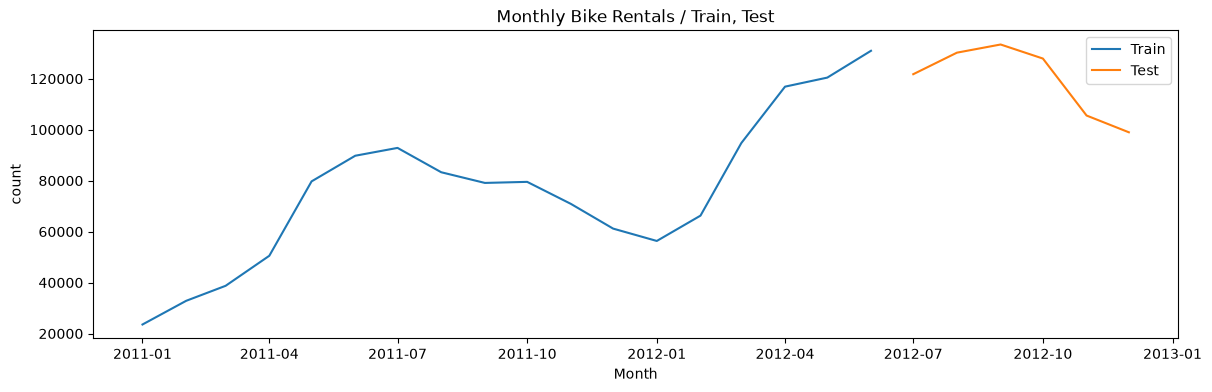

In [3]:
# TODO
# monthly 데이터를 Train / Test로 분리하세요.

train = monthly.iloc[:-6]
test = monthly.iloc[-6:]
print(f'''
Train 기간: {train.index.min().date()} ~ {train.index.max().date()}
Test 기간: {test.index.min().date()} ~ {test.index.max().date()}
''')

plt.figure(figsize=(14,4))
plt.plot(train.index, train['count'], label='Train')
plt.plot(test.index, test['count'], label='Test')
plt.title('Monthly Bike Rentals / Train, Test')
plt.xlabel('Month')
plt.ylabel('count')
plt.legend()
plt.show()

### Q1. 시계열 데이터에서 무작위로 Train / Test를 분리하면 안 되는 이유는 무엇인가요?

**답변:**  무작위로 섞어서 나누면 미래 시점의 데이터가 Train에 들어갈 수 있기 때문이다. 그러면 모델이 미래를 미리 보고 학습한 셈이 되어 실제로는 알 수 없는 정보를 사용하게 된다. 결과적으로 성능이 실제보다 좋게 평가된다. 실제 예측은 항상 과거 데이터로 미래를 맞히는 상황이므로, 과거를 Train으로, 그 이후를 Test로 나눠야 실제 상황과 같게 평가할 수 있다.

---

# 필수 2. ARIMA 모델 학습과 미래 값 예측

## 배경

ARIMA는 다음 세 가지 요소로 구성됩니다.

- **AR(p)**: 과거의 실제 값을 몇 개 사용할 것인가?
- **I(d)**: 차분을 몇 번 적용할 것인가?
- **MA(q)**: 과거의 예측 오차를 몇 개 사용할 것인가?

이번 실습에서는 교안과 동일하게 `ARIMA(2, 1, 1)`을 사용합니다.

## 문제 1. ARIMA(2, 1, 1)의 의미를 설명하세요.

### 요구사항

다음 세 값을 각각 설명합니다.

- `p = 2`
- `d = 1` 
- `q = 1` 

### Q2. 각각 무엇을 의미하나요?

**답변:**  
- `p = 2` 과거의 실제 값을 2개 사용해서 현재 값 예측
- `d = 1` 차분을 1회 실행
- `q = 1` 과거의 예측 오차를 1개 사용

## 문제 2. Train 데이터로 ARIMA 모델을 학습하세요.

### 요구사항

1. `statsmodels.tsa.arima.model`에서 `ARIMA`를 불러옵니다.
2. Train 데이터의 `count`를 사용합니다.
3. `order=(2, 1, 1)`을 지정합니다.
4. `fit()`으로 모델을 학습합니다.

### 확인 포인트

- Test 데이터를 학습에 사용하지 않았는가?
- `order=(p, d, q)`의 순서를 알고 있는가?

In [4]:
# TODO
# ARIMA(2, 1, 1) 모델을 생성하고 학습하세요.
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(
    train['count'],
    order=(2,1,1)
)
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  count   No. Observations:                   18
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -180.476
Date:                Wed, 30 Sep 2026   AIC                            368.953
Time:                        13:52:56   BIC                            372.285
Sample:                    01-01-2011   HQIC                           369.284
                         - 06-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5770      0.932      0.619      0.536      -1.249       2.403
ar.L2         -0.1038      0.541     -0.192      0.848      -1.165       0.957
ma.L1          0.2235      1.001      0.223      0.8

c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## 문제 3. Test 기간만큼 미래 값을 예측하세요.

### 요구사항

1. `forecast()`를 사용합니다.
2. `steps=len(test)`로 Test 기간과 같은 개수만큼 예측합니다.
3. 예측값의 인덱스를 Test 데이터의 인덱스와 동일하게 설정합니다.
4. `actual`, `predicted` 컬럼을 가진 DataFrame을 만듭니다.
5. 실제값과 예측값을 같은 그래프에 표시합니다.

### 확인 포인트

- Train 마지막 시점 이후의 값을 예측했는가?
- Test 길이와 예측값 개수가 같은가?
- Actual과 Predicted를 구분했는가?

            actual  predicted
month                        
2012-07-01  121769   139406.0
2012-08-01  130220   143189.0
2012-09-01  133425   144495.0
2012-10-01  127912   144855.0
2012-11-01  105551   144928.0
2012-12-01   98977   144932.0


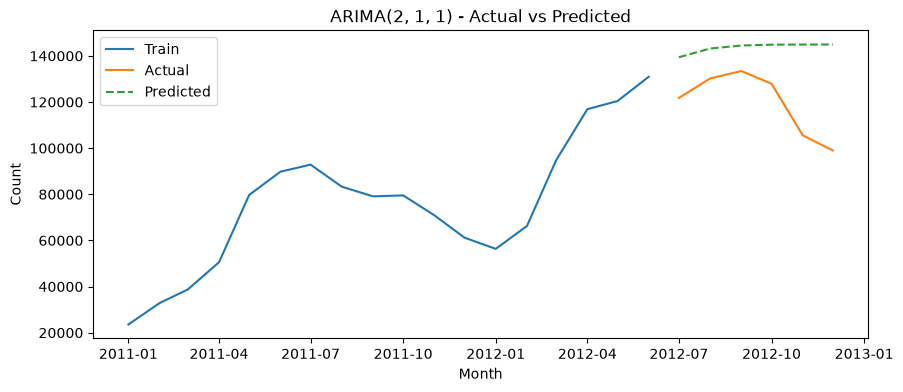

In [5]:
# TODO
# Test 기간만큼 예측하고 Actual / Predicted를 비교하세요.
forecast = model_fit.forecast(steps=len(test))
forecast.index = test.index

result = pd.DataFrame({
    'actual': test['count'],
    'predicted': forecast
})
print(result.round(0))

plt.figure(figsize=(10, 4))
plt.plot(train.index, train["count"], label='Train')
plt.plot(result.index, result["actual"], label="Actual")
plt.plot(result.index, result["predicted"], linestyle="--", label="Predicted")
plt.title("ARIMA(2, 1, 1) - Actual vs Predicted")
plt.xlabel("Month")
plt.ylabel("Count")
plt.legend()
plt.show()

### Q3. `steps=len(test)`는 무엇을 의미하나요?

**답변:**  Test 데이터의 길이만큼, 즉 Train의 마지막 시점 다음 달부터 6개월 뒤까지의 값을 예측한다는 의미

### Q4. Actual과 Predicted는 각각 무엇을 의미하나요?

**답변:** Actual은 Test 기간에 실제로 관특된 월별 대여량이고 Predicted는 Train 데이터로 학습한 ARIMA 모델이 같은 기간에 대해 예측한 값

---

# 과제 1. 정상성 진단을 반영한 ARIMA 예측과 예측 신뢰도 평가

## 배경

필수 1의 Train/Test 분리는 유지합니다. 과제에서는 Train 데이터의 정상성을 먼저 진단한 뒤 ARIMA의 차분 차수 d를 선택하여 모델을 다시 학습합니다. MAE·RMSE와 함께 **95% 예측 구간의 하한·상한**을 실제값과 비교합니다.

## 요구사항

1. 필수 1에서 만든 `train`, `test`를 사용합니다. 정상성 진단과 모델 설정에는 Train만 사용합니다.
2. Train의 `count`와 최근 3개 관측값의 이동평균을 그래프로 확인합니다. 원본에 ADF Test를 수행하고 검정통계량과 p-value를 출력합니다. 짧은 월별 자료이므로 이번 과제의 검정 설정은 `maxlag=1, regression="c", autolag="AIC"`로 통일합니다.
3. 유의수준 0.05에서 원본의 단위근 귀무가설을 기각하면 d=0을 우선 검토합니다. 기각하지 못하면 1차 차분한 Train에 같은 설정으로 ADF Test를 다시 수행하고 차분 그래프를 확인합니다. 차분 후 기각하면 d=1을 선택합니다. 차분 후에도 기각하지 못하면 추가 진단이 필요함을 명시하고, 이번 과제에서는 d=1을 잠정 설정하여 예측 과정과 한계를 함께 평가합니다. 선택 근거에 그래프 해석도 포함합니다.
4. **차분하지 않은 Train의 원본 `count`**를 `ARIMA(order=(2, d, 1))`에 전달해 학습합니다. 차분은 모델 내부에서 처리하므로 차분 데이터에 d=1을 다시 적용하지 않습니다. 필수 2의 모델·결과와 구분하여 과제용 변수를 사용합니다.
5. `get_forecast(steps=len(test))`로 Test 기간의 예측값과 95% 예측 구간을 구합니다. `predicted_mean`과 `conf_int(alpha=0.05)`를 활용합니다.
6. Test 날짜에 맞춰 `actual`, `predicted`, `lower_95`, `upper_95`를 가진 `task_result`를 만들고 출력합니다.
7. 과제 모델의 MAE·RMSE를 계산하고 의미를 설명합니다.
8. 실제값·예측값·95% 예측 구간을 같은 그래프에 표시합니다. 시점별 구간 폭과 실제값의 구간 포함 여부를 표에 추가하고, 구간 밖인 시점을 확인합니다.
9. 실제값과 구간의 비교 및 구간 폭을 근거로 예측 신뢰도를 해석합니다. 신뢰도가 낮다고 판단한 구간의 가능한 원인 또는 모델의 한계를 한 가지 이상 설명합니다. 구간 밖인 시점이 없더라도 구간 폭과 자료의 한계를 검토합니다.

> Test는 최종 평가에만 사용합니다. Test 결과를 보고 d나 다른 모델 설정을 다시 선택하지 않습니다. 월별 값은 제공된 CSV의 관측값 합계이며, 월 전체 날짜가 없으면 완전한 월간 총수요로 해석하지 않습니다.

### 확인 포인트

- Train만으로 정상성을 진단하고 d 선택 근거를 제시했는가?
- 1차 차분 후에도 귀무가설을 기각하지 못한 경우 잠정 모델의 한계를 밝혔는가?
- 원본 Train을 모델에 입력하여 이중 차분을 피했는가?
- MAE·RMSE와 실제값·예측값·예측 구간을 함께 확인했는가?
- 구간 밖 실제값과 구간 폭을 근거로 예측 신뢰도와 한계를 설명했는가?
- Q5~Q9에 모두 답했는가?


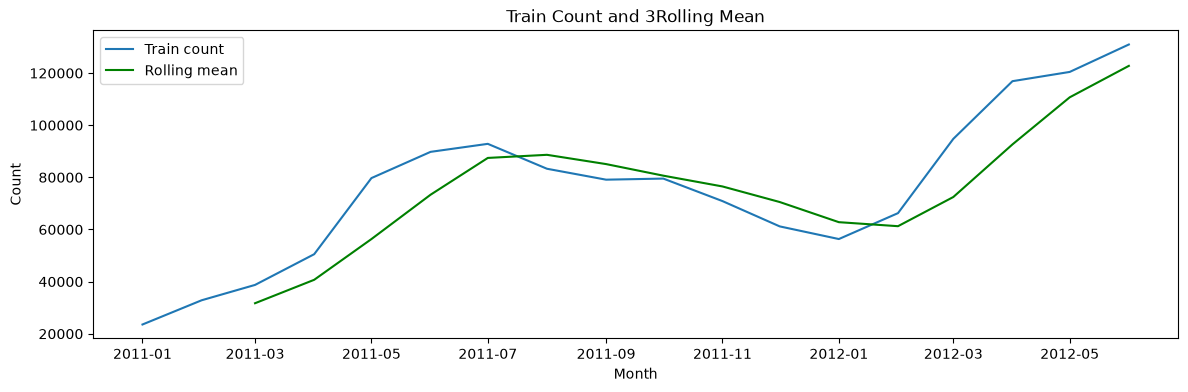

Train 원본 ADF 통계량: -1.571054621832968
Train 원본 ADF p-value: 0.49811537706392683
대립가설 기각 = 단위근이 존재하지 않는다 기각 -> 단위근이 존재한다 


C:\Users\mong0\AppData\Local\Temp\ipykernel_28020\2875864784.py:20: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_train = adfuller(train['count'], maxlag = 1, regression='c', autolag='AIC')


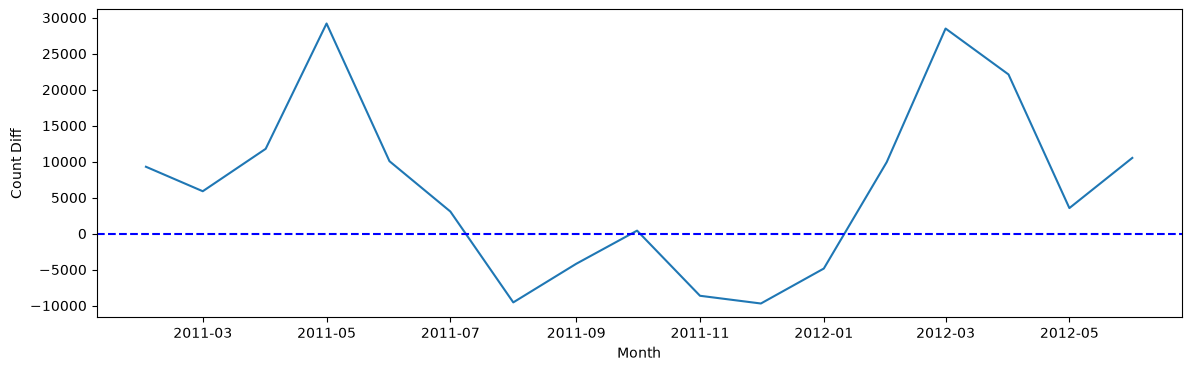

차분 후 대립가설 기각 -> 단위근이 존재한다 -> d = 1 선택 불가 -> 추가진단 필요(d = 1 잠정 설정)


C:\Users\mong0\AppData\Local\Temp\ipykernel_28020\2875864784.py:39: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_train_diff = adfuller(train_diff, maxlag=1, regression='c', autolag='AIC')
c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\MachineLearning-developed-MoonYoungheum\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\MachineLearning-developed-MoonY

,actual,predicted,lower_95,upper_95
month,,,,
2012-07-01,121769,139405.880749,121498.779335,157312.982163
2012-08-01,130220,143188.734859,106308.088273,180069.381446
2012-09-01,133425,144494.520944,91068.735687,197920.306200
2012-10-01,127912,144855.327175,77591.955731,212118.698619
2012-11-01,105551,144927.980297,65904.510142,223951.450453
2012-12-01,98977,144932.451482,55628.120917,234236.782048



mae: 23991.815917697942

rmse: 27541.81177277952



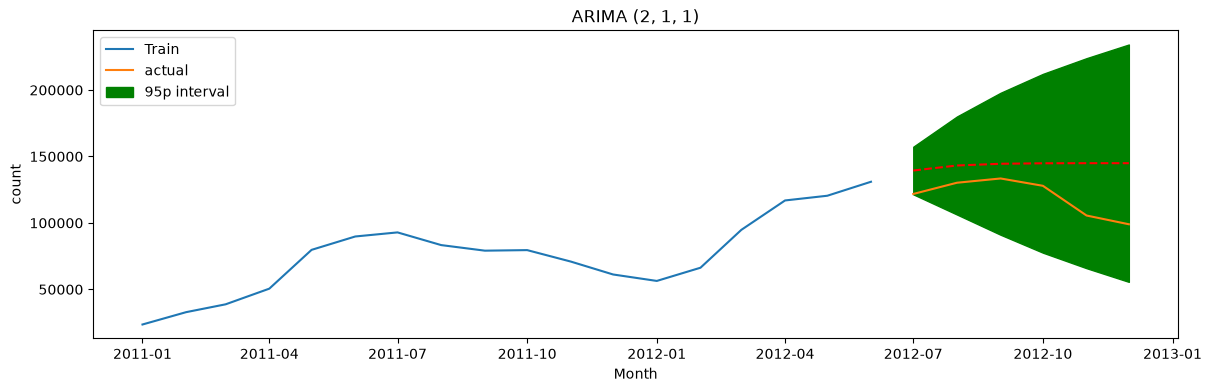

,actual,predicted,lower_95,upper_95,interval_width,in_interval,error
month,,,,,,,
2012-07-01,121769,139406.0,121499.0,157313.0,35814.0,True,-17637.0
2012-08-01,130220,143189.0,106308.0,180069.0,73761.0,True,-12969.0
2012-09-01,133425,144495.0,91069.0,197920.0,106852.0,True,-11070.0
2012-10-01,127912,144855.0,77592.0,212119.0,134527.0,True,-16943.0
2012-11-01,105551,144928.0,65905.0,223951.0,158047.0,True,-39377.0
2012-12-01,98977,144932.0,55628.0,234237.0,178609.0,True,-45955.0


구간 밖 시점: []


In [29]:
# TODO
# Train 정상성 진단 → d 선택 → 과제용 ARIMA 학습
# → 점예측·95% 예측 구간 → MAE·RMSE → 신뢰도 및 한계 해석
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

train_rolling = train['count'].rolling(window=3).mean()

plt.figure(figsize=(14,4))
plt.plot(train.index, train['count'], label='Train count')
plt.plot(train.index, train_rolling, color = 'green', label='Rolling mean')
plt.title('Train Count and 3Rolling Mean')
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend()
plt.show()

adf_train = adfuller(train['count'], maxlag = 1, regression='c', autolag='AIC')
print(f'Train 원본 ADF 통계량: {adf_train[0]}')
print(f'Train 원본 ADF p-value: {adf_train[1]}')

if adf_train[1] < 0.05:
    print(f'귀무가설 기각 = 단위근이 존재한다가 기각 -> 단위근이 존재하지 않는다.')
else: 
    print(f'대립가설 기각 = 단위근이 존재하지 않는다 기각 -> 단위근이 존재한다 ')


    train_diff = train['count'].diff().dropna()

    plt.figure(figsize=(14,4))
    plt.plot(train_diff.index, train_diff)
    plt.axhline(0, color='blue', linestyle='--')
    plt.xlabel('Month')
    plt.ylabel('Count Diff')
    plt.show()

    adf_train_diff = adfuller(train_diff, maxlag=1, regression='c', autolag='AIC')
    if adf_train[1] < 0.05:
        print(f'차분 후 귀무가설 기각 -> 단위근이 존재하지 않는다 -> d = 1 선택')
    else: 
        print(f'차분 후 대립가설 기각 -> 단위근이 존재한다 -> d = 1 선택 불가 -> 추가진단 필요(d = 1 잠정 설정)')

    d = 1

#차분하지 않은 Train 활용
a_model = ARIMA(
    train['count'],
    order=(2, d, 1)
)
a = a_model.fit()
a_forecast = a.get_forecast(steps=len(test))
a_pred = a_forecast.predicted_mean
a_ci = a_forecast.conf_int(alpha=0.05) 

a_result = pd.DataFrame({
    'actual': test['count'].values,
    'predicted': a_pred.values,
    'lower_95': a_ci.iloc[:,0].values,
    'upper_95': a_ci.iloc[:,1].values
}, index=test.index)
display(a_result)

#MAE, RMSE
a_mae = mean_absolute_error(a_result['actual'], a_result['predicted'])
a_rmse = mean_squared_error(a_result['actual'], a_result['predicted']) ** 0.5
print(f'''
mae: {a_mae}
\nrmse: {a_rmse}
''')

#그래프, 구간 폭
plt.figure(figsize=(14,4))
plt.plot(train.index, train['count'], label='Train')
plt.plot(a_result.index, a_result['predicted'], linestyle='--', color='red')
plt.plot(a_result.index, a_result['actual'], label='actual')
plt.fill_between(a_result.index, a_result['lower_95'], a_result['upper_95'], color='green', label='95p interval')
plt.title('ARIMA (2, 1, 1)')
plt.xlabel('Month')
plt.ylabel('count')
plt.legend()
plt.show()

a_result['interval_width'] = a_result['upper_95'] - a_result['lower_95']
a_result['in_interval'] = (a_result['actual'] >= a_result['lower_95']) & (a_result['actual'] <= a_result['upper_95'])
a_result['error'] = a_result['actual'] - a_result['predicted']
display(a_result.round(0))

print(f"구간 밖 시점: {list(a_result[~a_result['in_interval']].index.date)}")

### Q5. MAE는 어떻게 해석할 수 있나요?

**답변:** MAE는 실제값과 예측값 차이의 절댓값 평균. 과제 모델의 MAE는 약 23,992이므로, Test 6개월 동안 한 달 평균 약 24,000건 정도 예측이 빗나갔다고 해석할 수 있다. Test 기간 실제 월별 대여량이 약 99,000에서 133,000 수준이니, 대략 20% 안팎의 오차이다. 또 error가 모두 음수인 것을 보면, 모델이 모든 달에서 실제보다 크게 예측 했다.


### Q6. RMSE가 MAE보다 큰 오차에 더 민감한 이유는 무엇인가요?

**답변:** RMSE는 오차를 제곱한 뒤 평균을 내고 루트를 씌우기 때문. 제곱하면 큰 오차는 훨씬 더 커지므로 결과에 더 큰 영향을 준다. 이번 결과에서도 11월(-39,377)과 12월(-45,955)의 큰 오차 때문에 RMSE(약 27,542)가 MAE(약 23,992)보다 크게 나왔다. 두 값의 차이가 크다는 건 특정 시점에 큰 오차가 몰려 있다는 뜻이다.


### Q7. Train 데이터의 ADF 검정 결과와 그래프를 근거로 d를 어떻게 선택했나요? 정상성 판단에 남아 있는 한계는 무엇인가요?

**답변:** Train 원본의 ADF p-value는 약 0.498로 0.05보다 커서 귀무가설을 기각하지 못했다. 그래서 1차 차분 후 다시 검정했지만, p-value가 약 0.295로 여전히 0.05보다 커서 기각하지 못했다. 그래프를 봐도 원본은 3개월 이동평균이 2011년 여름까지 오르고 겨울에 내렸다가 2012년에 다시 크게 오른다. 차분 그래프도 0을 중심으로 고르게 움직이기보다 봄에 큰 +, 겨울에 −가 나타나는 계절 패턴이 남아 있다. 따라서 추가 진단이 필요하고, 이번 과제에서는 조건대로 d = 1을 잠정 설정했다.
남아 있는 한계는 다음과 같음
Train이 18개월밖에 없어서 ADF 검정의 신뢰도가 낮다.
1년 주기 계절성이 강한데, 1차 차분만으로는 계절성이 제거되지 않는다.

### Q8. Test 실제값이 95% 예측 구간 밖에 나타난 시점은 언제이며, 구간 폭은 시점별로 어떻게 달라지나요? 이를 근거로 예측 신뢰도를 설명하세요.

**답변:** 6개월 모두 실제값이 95% 예측 구간 안에 있어서 구간 밖인 시점은 없다. 다만 2012-07은 실제값(121,769)이 하한(121,499)보다 겨우 약 270 높아서, 거의 경계에 걸쳐 있었다.  구간 폭은 7월 약 35,800에서 12월 약 178,600으로 예측 시점이 멀어질수록 계속 넓어진다. 먼 미래일수록 불확실성이 누적되기 때문이다. 따라서 모두 구간 안에 있다는 것만으로 신뢰도가 높다고 보기는 어렵다. 뒤로 갈수록 구간이 너무 넓어져서 실제값이 들어가는 게 당연한 수준이고, 예측값 자체는 모든 달에서 실제보다 높게 빗나갔기 때문이다.


### Q9. 예측 신뢰도가 낮다고 판단한 시점 또는 구간은 어디인가요? 가능한 원인이나 모델의 한계를 한 가지 이상 설명하세요.

**답변:** 2012-11~12월의 신뢰도가 가장 낮다고 판단했다. 오차가 -39,377과 -45,955로 가장 크고, 구간 폭도 158,000~179,000으로 월 대여량 자체보다 넓어서 정보가 거의 없는 수준이다.
가능한 원인은 정상성을 만족하지 못한 부분에 있을 수 있다. 정상성을 만족하지 못하고 d = 1이라고 잠정적 설정하고 만든 모델이라 예측 신뢰도에도 한계가 있다.


---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 시계열 Train/Test 분리에서 가장 중요한 원칙은 무엇인가요?
2. ARIMA의 `p`, `d`, `q`는 각각 무엇을 의미하나요?
3. `forecast(steps=6)`은 무엇을 의미하나요?
4. Actual과 Predicted의 차이는 무엇인가요?
5. MAE와 RMSE는 값이 클수록 좋은 지표인가요, 작을수록 좋은 지표인가요?

- 시계열 Train/Test 분리에서 가장 중요한 원칙: 시간 순서를 유지해서, 과거를 Train으로 쓰고 그 이후를 Test로 써야 합니다.
- ARIMA의 p, d, q: p는 사용할 과거 실제값의 개수, d는 차분 횟수, q는 사용할 과거 예측 오차의 개수입니다.
- forecast(steps=6)의 의미: 학습 데이터 마지막 시점 다음부터 6개 시점(6개월)의 값을 예측한다는 뜻입니다.
- Actual과 Predicted의 차이: Actual은 실제로 관측된 값이고, Predicted는 모델이 예측한 값입니다.
MAE와 RMSE: 오차를 나타내는 지표이므로 작을수록 좋습니다.